# Notebook 07 — Resultado e análise do Pipeline 3 com OpenF1

Este notebook analisa os resultados do **Pipeline 3 — Mallows + Plackett–Luce + OpenF1**.

O objetivo aqui é interpretar o desempenho do modelo, avaliar a qualidade probabilística das previsões e entender como o contexto da corrida, vindo da OpenF1, ajuda a explicar os acertos e erros do pipeline.

A análise considera:

- treino em 2019–2023;
- validação em 2024;
- teste em 2025;
- avaliação determinística com Top-3, Top-5 e Kendall τ;
- avaliação probabilística com Ranked Probability Score;
- comparação contra baseline uniforme;
- contexto OpenF1: grid, DNF e eventos de corrida.

## 1. Leitura dos dados gerados pelo Pipeline 3

Este notebook parte dos arquivos exportados pelo próprio pipeline, principalmente:

```text
src/pipeline_openf1/outputs/nb_data_p3.pkl
data/openf1/processed/race_context_2023_2025.csv
data/openf1/processed/openf1_coverage_report_2024_2025.csv
```

O arquivo `nb_data_p3.pkl` contém os objetos de resultado usados para gerar tabelas e gráficos. Os arquivos em `data/openf1/processed` contêm o contexto da OpenF1 e o relatório de cobertura das corridas avaliadas.

In [1]:
from pathlib import Path
import pickle
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

def find_project_root(start=None):
    # Procura a raiz do projeto a partir do diretório atual.
    start = Path.cwd() if start is None else Path(start)
    candidates = [start, *start.parents]
    for p in candidates:
        if (p / "src").exists() or (p / "data").exists():
            return p
    return start

PROJECT_ROOT = find_project_root()

OUTPUT_DIR = PROJECT_ROOT / "src" / "pipeline_openf1" / "outputs"
OPENF1_PROCESSED_DIR = PROJECT_ROOT / "data" / "openf1" / "processed"

NB_DATA_PATH = OUTPUT_DIR / "nb_data_p3.pkl"
CONTEXT_PATH = OPENF1_PROCESSED_DIR / "race_context_2023_2025.csv"
COVERAGE_PATH = OPENF1_PROCESSED_DIR / "openf1_coverage_report_2024_2025.csv"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("NB_DATA_PATH:", NB_DATA_PATH)
print("CONTEXT_PATH:", CONTEXT_PATH)
print("COVERAGE_PATH:", COVERAGE_PATH)

PROJECT_ROOT: C:\Users\guiga\OneDrive\Documentos\Projeto-Formula1
NB_DATA_PATH: C:\Users\guiga\OneDrive\Documentos\Projeto-Formula1\src\pipeline_openf1\outputs\nb_data_p3.pkl
CONTEXT_PATH: C:\Users\guiga\OneDrive\Documentos\Projeto-Formula1\data\openf1\processed\race_context_2023_2025.csv
COVERAGE_PATH: C:\Users\guiga\OneDrive\Documentos\Projeto-Formula1\data\openf1\processed\openf1_coverage_report_2024_2025.csv


In [2]:
nb_data = {}
if NB_DATA_PATH.exists():
    with open(NB_DATA_PATH, "rb") as f:
        nb_data = pickle.load(f)
    print("Arquivo nb_data_p3.pkl carregado.")
    print("Chaves disponíveis:", list(nb_data.keys()))
else:
    print("Arquivo nb_data_p3.pkl não encontrado neste ambiente.")
    print("As células seguintes usam valores de referência da execução do Pipeline 3 quando necessário.")

Arquivo nb_data_p3.pkl carregado.
Chaves disponíveis: ['state', 'train_records', 'val_records', 'test_records', 'all_drivers', 'val_evals', 'test_evals', 'val_rps', 'test_rps', 'val_rps_summary', 'test_rps_summary', 'val_distributions', 'test_distributions', 'val_snapshots', 'test_snapshots', 'dnf_analysis', 'grid_vs_finish', 'ctx_df', 'coverage_report', 'config']


In [3]:
def safe_read_csv(path):
    if Path(path).exists():
        return pd.read_csv(path)
    return pd.DataFrame()

context_df = safe_read_csv(CONTEXT_PATH)
coverage_df = safe_read_csv(COVERAGE_PATH)

print("Contexto OpenF1:", context_df.shape)
print("Coverage report:", coverage_df.shape)

if not context_df.empty:
    display(context_df.head())

if not coverage_df.empty:
    display(coverage_df.head())

Contexto OpenF1: (70, 73)
Coverage report: (39, 13)


,context_schema_version,season,race,race_key,meeting_name,meeting_key,session_key,quali_session_key,has_session_result,sc_count,...,grid_COL,dnf_COL,grid_DOO,dnf_DOO,grid_HAD,grid_BOR,grid_ANT,dnf_ANT,dnf_BOR,dnf_HAD
0,2,2023,Sakhir,sakhir,Bahrain Grand Prix,1141,7953,7768,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,2023,Jeddah,jeddah,Saudi Arabian Grand Prix,1142,7779,7775,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,2023,Melbourne,melbourne,Australian Grand Prix,1143,7787,7783,1,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2,2023,Baku,baku,Azerbaijan Grand Prix,1207,9070,9064,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2,2023,Miami,miami,Miami Grand Prix,1208,9078,9074,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,season,race,race_key,has_context,openf1_race,grid_source,has_grid,grid_driver_count,has_session_result,has_race_control,dnf_driver_count,missing_reason,openf1_race_key
0,2024,Bahrain,sakhir,1,Sakhir,starting_grid_quali,1,20,1,1,20,matched,sakhir
1,2024,Saudi Arabia,jeddah,1,Jeddah,starting_grid_quali,1,20,1,1,20,matched,jeddah
2,2024,Australia,melbourne,1,Melbourne,starting_grid_quali,1,19,1,1,19,matched,melbourne
3,2024,Japan,suzuka,1,Suzuka,starting_grid_quali,1,20,1,1,20,matched,suzuka
4,2024,China,shanghai,1,Shanghai,starting_grid_quali,1,20,1,1,20,matched,shanghai


## 2. Cobertura OpenF1

A cobertura do contexto é uma etapa importante porque garante que as corridas avaliadas em validação e teste foram associadas corretamente aos dados da OpenF1.

Na execução analisada, a cobertura das 39 corridas de validação/teste foi:

| Item | Resultado |
|---|---:|
| Corridas históricas avaliadas | 39 |
| Corridas com contexto OpenF1 | 39 |
| Corridas com contexto OpenF1 (%) | 100% |
| Corridas com grid de piloto | 39 |
| Corridas com grid de piloto (%) | 100% |
| Corridas com `starting_grid` oficial | 39 |
| Corridas com fallback de qualifying | 0 |
| Corridas indisponíveis ou sem match | 0 |

Isso significa que, para a etapa de avaliação do Pipeline 3, o contexto OpenF1 está completo. O pipeline também gerou um arquivo de contexto com 70 corridas entre 2023 e 2025.

In [4]:
if not coverage_df.empty:
    total = len(coverage_df)

    def col_exists(name):
        return name in coverage_df.columns

    print(f"Corridas no coverage report: {total}")

    for col in ["has_openf1_context", "has_context", "has_grid", "has_official_grid"]:
        if col_exists(col):
            print(f"{col}: {coverage_df[col].sum()} / {total}")

    for col in ["match_status", "status", "grid_source"]:
        if col_exists(col):
            print(f"\nDistribuição de {col}:")
            display(coverage_df[col].value_counts(dropna=False).to_frame("qtd"))
else:
    coverage_reference = pd.DataFrame({
        "Indicador": [
            "Corridas históricas avaliadas",
            "Com contexto OpenF1",
            "Com grid de piloto",
            "Starting grid oficial",
            "Qualifying fallback",
            "Indisponível/sem match",
        ],
        "Quantidade": [39, 39, 39, 39, 0, 0],
        "Percentual": ["100%", "100%", "100%", "100%", "0%", "0%"],
    })
    display(coverage_reference)

Corridas no coverage report: 39
has_context: 39 / 39
has_grid: 39 / 39

Distribuição de grid_source:


,qtd
grid_source,
starting_grid_quali,39


## 3. Como interpretar as métricas

O Pipeline 3 usa dois tipos de avaliação.

### Métricas determinísticas

| Métrica | Interpretação |
|---|---|
| Top-3 | Proporção de acerto entre os três primeiros previstos e reais |
| Top-5 | Proporção de acerto entre os cinco primeiros previstos e reais |
| Kendall τ | Similaridade entre a ordem prevista e a ordem real |

As métricas determinísticas são úteis para entender se o modelo acertou os principais pilotos e a estrutura geral do ranking.

### Métrica probabilística

A métrica principal do pipeline é o **Ranked Probability Score (RPS)**.

\[
RPS = \frac{1}{K}\sum_{k=1}^{K}
\left(F_{\text{prevista}}(k)-F_{\text{real}}(k)\right)^2
\]

A interpretação é:

```text
RPS menor = previsão probabilística melhor
RPS igual a 0 = previsão perfeita
```

O ganho sobre o baseline é calculado como:

```text
ganho = RPS_baseline - RPS_modelo
```

Portanto:

```text
ganho positivo = modelo melhor que baseline
ganho negativo = baseline melhor que modelo
```

O baseline usado é uniforme. Ele serve como referência mínima: se o modelo vence o baseline, então suas probabilidades carregam informação útil.

## 4. Resultado geral do Pipeline 3

O resumo final da execução foi:

| Split | Top-3 | Top-5 | Kendall τ | RPS Modelo | RPS Baseline | Ganho médio | Melhoria |
|---|---:|---:|---:|---:|---:|---:|---:|
| Validação 2024 | 0.347 | 0.575 | 0.400 | 0.1270 | 0.1762 | 0.0492 | 27.9% |
| Teste 2025 | 0.533 | 0.667 | 0.405 | 0.1421 | 0.1769 | 0.0347 | 19.6% |

A validação de 2024 teve RPS médio menor que o teste de 2025. Como menor RPS é melhor, o modelo foi probabilisticamente mais forte em 2024.

Por outro lado, as métricas determinísticas foram melhores em 2025:

```text
Top-3 2024: 0.347
Top-3 2025: 0.533

Top-5 2024: 0.575
Top-5 2025: 0.667
```

Essa diferença é importante. Em 2025, o modelo acertou mais pilotos no Top-3 e Top-5, mas suas distribuições probabilísticas ficaram menos precisas do que em 2024. Ou seja, ele acertou mais nomes entre os primeiros, mas distribuiu a massa de probabilidade com menor qualidade.

In [5]:
summary_results = pd.DataFrame({
    "Split": ["Validação 2024", "Teste 2025"],
    "Top-3": [0.347, 0.533],
    "Top-5": [0.575, 0.667],
    "Kendall τ": [0.400, 0.405],
    "RPS Modelo": [0.1270, 0.1421],
    "RPS Baseline": [0.1762, 0.1769],
    "Ganho médio": [0.0492, 0.0347],
    "Melhoria": ["27.9%", "19.6%"],
})
display(summary_results)

,Split,Top-3,Top-5,Kendall τ,RPS Modelo,RPS Baseline,Ganho médio,Melhoria
0,Validação 2024,0.347,0.575,0.400,0.1270,0.1762,0.0492,27.9%
1,Teste 2025,0.533,0.667,0.405,0.1421,0.1769,0.0347,19.6%


In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(summary_results))
width = 0.35

ax.bar(x - width/2, summary_results["RPS Modelo"], width, label="Pipeline 3")
ax.bar(x + width/2, summary_results["RPS Baseline"], width, label="Baseline uniforme")

ax.set_xticks(x)
ax.set_xticklabels(summary_results["Split"])
ax.set_ylabel("RPS médio")
ax.set_title("RPS médio: Pipeline 3 vs baseline uniforme")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.show()

## 5. Validação 2024 — análise detalhada

A validação de 2024 foi o bloco com melhor desempenho probabilístico.

Resultado médio:

```text
Top-3 médio:      0.347
Top-5 médio:      0.575
Kendall médio:    0.400
RPS médio:        0.1270
Baseline médio:   0.1762
Ganho médio:      0.0492
Melhoria:         27.9%
```

O ponto central é que o modelo ficou acima do baseline uniforme em todas as corridas da validação. Isso indica que, mesmo nas corridas mais difíceis, as probabilidades geradas pelo Pipeline 3 foram mais informativas do que uma previsão uniforme.

### 5.1 Melhores corridas de 2024

As melhores corridas de 2024 por RPS foram:

| Corrida | RPS | Ganho | Top-3 | Kendall |
|---|---:|---:|---:|---:|
| Netherlands | ≈ 0.096 | ≈ 0.076 | 0.667 | 0.467 |
| Singapore | ≈ 0.099 | ≈ 0.076 | 0.667 | 0.636 |
| Belgium | ≈ 0.103 | ≈ 0.074 | 0.333 | 0.576 |
| Hungary | ≈ 0.109 | ≈ 0.067 | 0.667 | 0.418 |
| Bahrain | ≈ 0.110 | ≈ 0.063 | 0.333 | 0.511 |

Essas corridas mostram que o modelo foi forte quando a estrutura competitiva ficou próxima do histórico aprendido.

Belgium 2024 é um exemplo interessante: mesmo com Top-3 de 0.333, o RPS foi muito bom. Isso mostra que o modelo pode errar parte do pódio e ainda assim produzir uma distribuição probabilística de boa qualidade para o ranking geral.

### 5.2 Corridas mais difíceis de 2024

As corridas mais difíceis de 2024 foram:

| Corrida | RPS | Ganho | Top-3 | Kendall | Contexto |
|---|---:|---:|---:|---:|---|
| Australia | ≈ 0.160 | ≈ 0.017 | 0.000 | 0.091 | VSC e muitas yellow flags |
| Brazil | ≈ 0.157 | ≈ 0.022 | 0.333 | 0.238 | SC, VSC e muitas yellow flags |
| Great Britain | ≈ 0.155 | ≈ 0.022 | 0.667 | 0.576 | RPS alto apesar de boa ordem parcial |
| Austria | ≈ 0.147 | ≈ 0.026 | 0.000 | 0.244 | Corrida difícil para Top-3 |
| Azerbaijan | ≈ 0.148 | ≈ 0.028 | 0.000 | 0.236 | Muitos VSC/yellow flags |

Essas corridas mostram dois tipos de dificuldade:

1. **Erro de ordenação real**, quando Top-3 e Kendall são baixos.
2. **Erro de calibração probabilística**, quando o modelo acerta parte da ordem, mas distribui mal as probabilidades.

Great Britain 2024 é um exemplo do segundo caso: Top-3 e Kendall foram bons, mas o RPS ficou alto.

## 6. Teste 2025 — análise detalhada

O teste de 2025 avalia a capacidade de generalização do Pipeline 3.

Resultado médio:

```text
Top-3 médio:      0.533
Top-5 médio:      0.667
Kendall médio:    0.405
RPS médio:        0.1421
Baseline médio:   0.1769
Ganho médio:      0.0347
Melhoria:         19.6%
```

O modelo continuou vencendo o baseline em todas as corridas, mas a margem foi menor que em 2024. Isso sugere que 2025 foi mais difícil para a calibração probabilística, mesmo com melhor desempenho determinístico.

### 6.1 Melhores corridas de 2025

As melhores corridas de 2025 por RPS foram:

| Corrida | RPS | Ganho | Top-3 | Kendall |
|---|---:|---:|---:|---:|
| Canada | ≈ 0.120 | ≈ 0.057 | 0.333 | 0.606 |
| Emilia-Romagna | ≈ 0.121 | ≈ 0.056 | 0.667 | 0.394 |
| Japan | ≈ 0.121 | ≈ 0.052 | 0.667 | 0.422 |
| Saudi Arabia | ≈ 0.123 | ≈ 0.054 | 0.333 | 0.667 |
| Spain | ≈ 0.129 | ≈ 0.047 | 0.667 | 0.364 |

Canada 2025 e Saudi Arabia 2025 são bons exemplos de desempenho estrutural: o Top-3 não foi máximo, mas o Kendall foi alto, indicando que a ordem relativa geral foi bem capturada.

Emilia-Romagna, Japan e Spain tiveram bom Top-3 e bom RPS, então são casos em que a previsão determinística e a probabilística caminharam juntas.

### 6.2 Corridas mais difíceis de 2025

As corridas mais difíceis de 2025 foram:

| Corrida | RPS | Ganho | Top-3 | Kendall | Contexto |
|---|---:|---:|---:|---:|---|
| Great Britain | ≈ 0.163 | ≈ 0.017 | 0.333 | 0.486 | Muitos SC, VSC e yellow flags |
| Australia | ≈ 0.161 | ≈ 0.018 | 0.667 | 0.333 | Corrida muito instável |
| Austria | ≈ 0.157 | ≈ 0.022 | 0.667 | 0.275 | Ordem geral difícil |
| China | ≈ 0.155 | ≈ 0.024 | 0.333 | 0.055 | Kendall muito baixo |
| Belgium | ≈ 0.155 | ≈ 0.018 | 0.667 | 0.511 | Muitas yellow flags |

China 2025 é o pior caso em Kendall, com valor próximo de zero. Isso indica que a ordem prevista ficou pouco relacionada à ordem final.

Australia 2025 e Great Britain 2025 mostram outro padrão: o modelo ainda acertou parte dos nomes relevantes, mas a distribuição probabilística ficou distante da realidade.

## 7. Evolução do RPS

O gráfico de evolução do RPS mostra a trajetória corrida a corrida do modelo contra o baseline.

A leitura principal é:

- o Pipeline 3 fica abaixo do baseline em todas as corridas;
- 2024 tem RPS médio menor;
- 2025 permanece melhor que o baseline, mas mais próximo dele;
- os picos de erro aparecem em corridas mais instáveis ou com mudança forte de ordem.

Se o arquivo de imagem já tiver sido gerado pelo pipeline, a célula abaixo exibe o gráfico salvo.

In [7]:
from IPython.display import Image, display

plot_paths = {
    "Evolução do RPS": OUTPUT_DIR / "viz1_rps_evolution_p3.png",
    "Ganho RPS": OUTPUT_DIR / "viz2_rps_gain_p3.png",
    "Impacto de eventos": OUTPUT_DIR / "viz3_context_impact_p3.png",
    "Probabilidades de vitória": OUTPUT_DIR / "viz4_win_probabilities_p3.png",
    "Comparação de RPS": OUTPUT_DIR / "viz5_pipeline_comparison.png",
}

for title, path in plot_paths.items():
    print(title, "->", path.exists(), path)

Evolução do RPS -> True C:\Users\guiga\OneDrive\Documentos\Projeto-Formula1\src\pipeline_openf1\outputs\viz1_rps_evolution_p3.png
Ganho RPS -> True C:\Users\guiga\OneDrive\Documentos\Projeto-Formula1\src\pipeline_openf1\outputs\viz2_rps_gain_p3.png
Impacto de eventos -> True C:\Users\guiga\OneDrive\Documentos\Projeto-Formula1\src\pipeline_openf1\outputs\viz3_context_impact_p3.png
Probabilidades de vitória -> True C:\Users\guiga\OneDrive\Documentos\Projeto-Formula1\src\pipeline_openf1\outputs\viz4_win_probabilities_p3.png
Comparação de RPS -> True C:\Users\guiga\OneDrive\Documentos\Projeto-Formula1\src\pipeline_openf1\outputs\viz5_pipeline_comparison.png


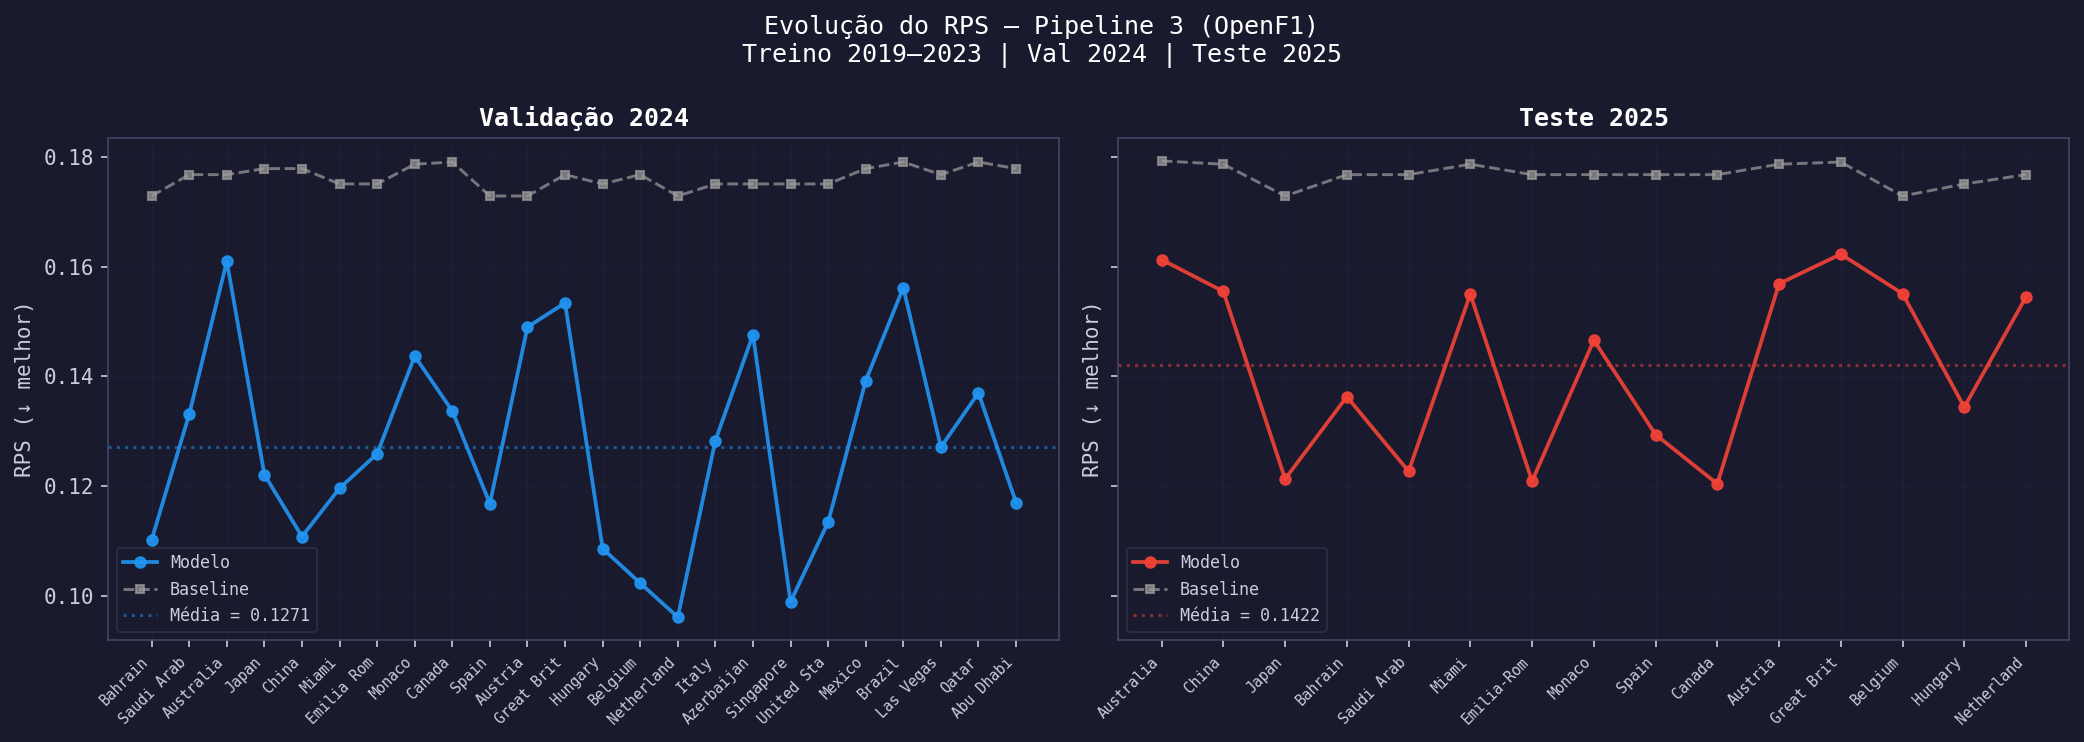

In [8]:
path = plot_paths["Evolução do RPS"]
if path.exists():
    display(Image(filename=str(path)))
else:
    print("Gráfico de evolução do RPS não encontrado. Rode o Pipeline 3 para gerar a imagem.")

## 8. Ganho sobre o baseline uniforme

O ganho sobre o baseline é uma das evidências mais fortes do Pipeline 3.

Em todas as corridas avaliadas:

```text
RPS_modelo < RPS_baseline
```

Portanto:

```text
ganho > 0
```

Isso mostra que o modelo não está apenas produzindo rankings plausíveis; ele produz distribuições de probabilidade mais informativas do que uma distribuição uniforme.

A validação de 2024 teve ganho médio de aproximadamente 0.0492. O teste de 2025 teve ganho médio de aproximadamente 0.0347. A queda no ganho em 2025 indica que a temporada de teste foi mais difícil, mas o modelo continuou útil.

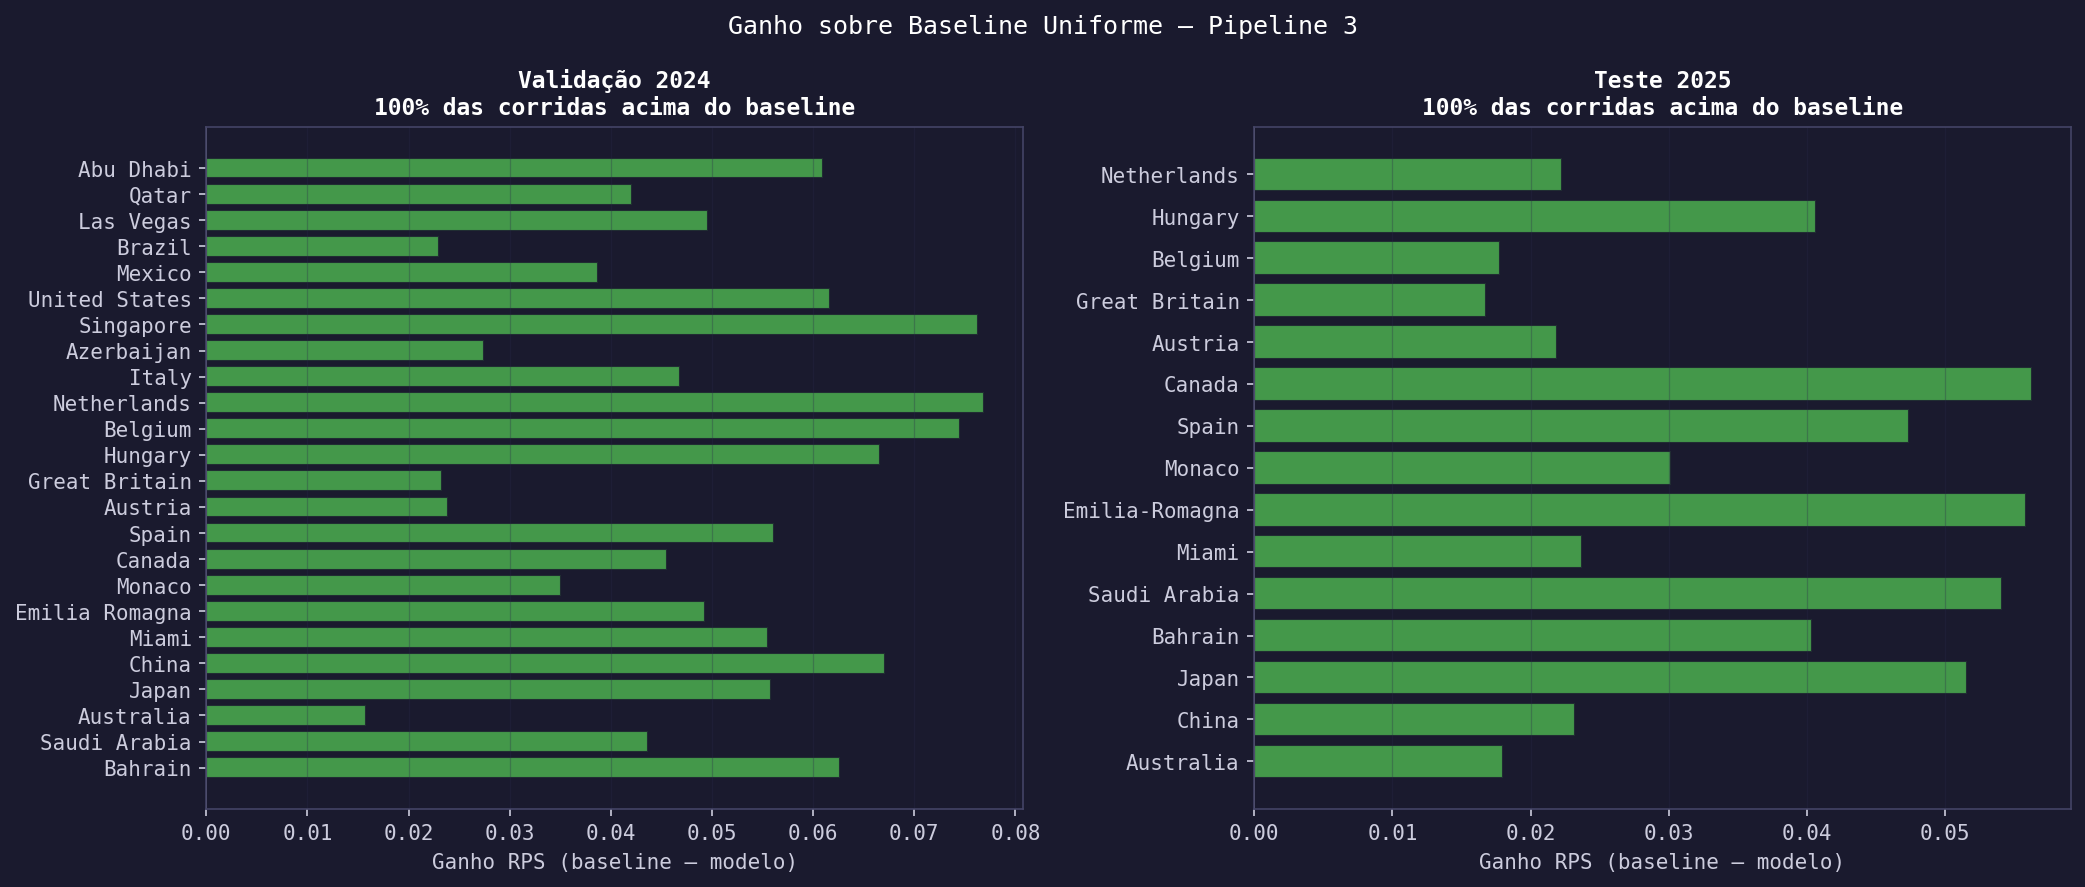

In [9]:
path = plot_paths["Ganho RPS"]
if path.exists():
    display(Image(filename=str(path)))
else:
    print("Gráfico de ganho RPS não encontrado. Rode o Pipeline 3 para gerar a imagem.")

## 9. Impacto dos eventos de corrida

A OpenF1 agrega valor principalmente na interpretação dos resultados. Com as informações de race control, é possível relacionar erros do modelo com características da corrida.

As variáveis analisadas são:

- Safety Car;
- Virtual Safety Car;
- Red Flag;
- Yellow Flags.

A interpretação deve ser feita com cuidado: esses eventos são observados durante a corrida, então eles explicam o erro depois que a corrida aconteceu. Eles não devem ser tratados como informação disponível antes da corrida.

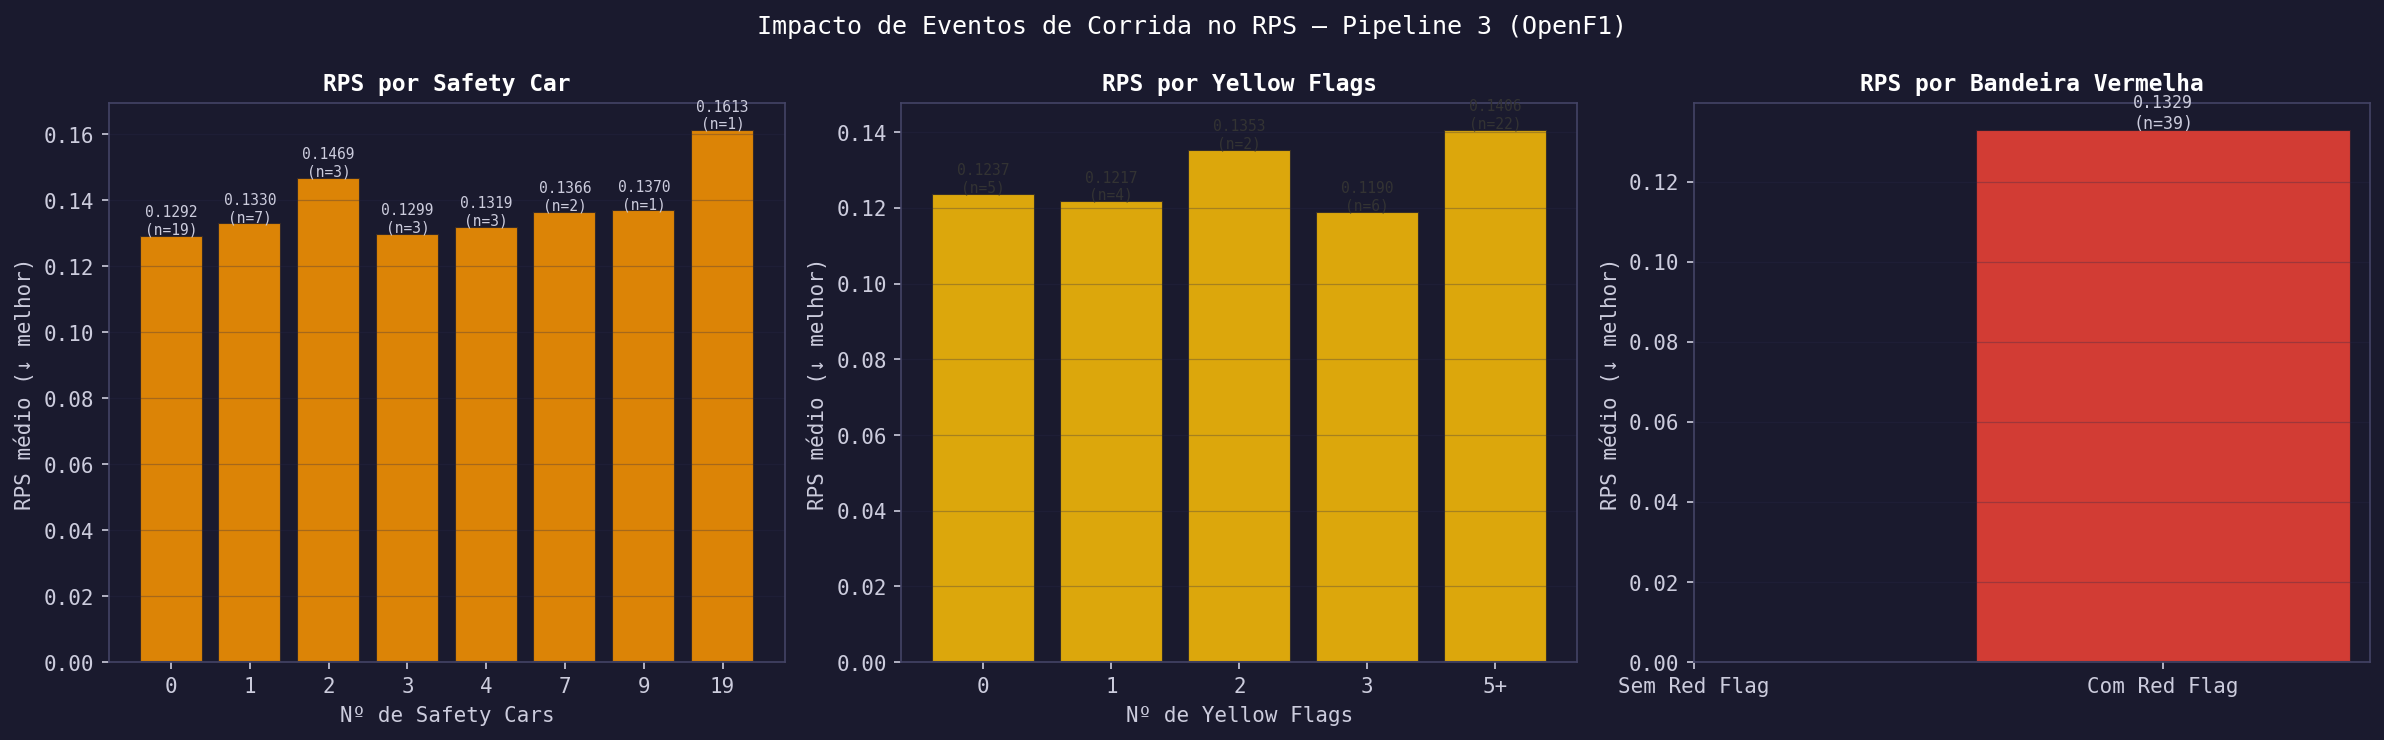

In [10]:
path = plot_paths["Impacto de eventos"]
if path.exists():
    display(Image(filename=str(path)))
else:
    print("Gráfico de impacto de eventos não encontrado. Rode o Pipeline 3 para gerar a imagem.")

### 9.1 Safety Car

As corridas com eventos extremos de Safety Car tendem a apresentar RPS mais alto. Isso é coerente com a natureza da Fórmula 1: Safety Cars alteram gaps, estratégias de pit stop e a ordem relativa dos pilotos.

No entanto, a relação não precisa ser perfeitamente monotônica. O número de corridas por grupo é pequeno e a contagem pode representar mensagens/eventos de race control, não necessariamente períodos únicos consolidados.

A leitura recomendada é:

> Safety Car está associado a maior instabilidade da corrida e ajuda a explicar parte dos piores RPS.

### 9.2 Yellow Flags

Yellow flags apresentam um sinal interpretativo forte. Corridas com muitas yellow flags tendem a ter RPS pior.

Isso sugere que incidentes e interrupções locais afetam a previsibilidade do ranking final.

A frase adequada para o TCC é:

> Corridas com maior quantidade de yellow flags tendem a apresentar maior erro probabilístico, indicando que eventos de pista aumentam a dificuldade de previsão.

### 9.3 Virtual Safety Car

O VSC segue uma lógica parecida com Safety Car. Ele pode alterar estratégia e gaps sem neutralizar a corrida da mesma forma, mas ainda modifica o desenvolvimento esperado da prova.

Exemplos como Azerbaijan 2024, Miami 2025 e Great Britain 2025 indicam que VSCs podem aparecer em corridas com RPS elevado.

### 9.4 Red Flag

No conjunto avaliado, a variável de red flag não deve ser usada isoladamente como conclusão principal se ela não separar bem as corridas em grupos distintos.

A recomendação analítica é usá-la como variável exploratória, não como eixo central da conclusão.

## 10. Grid de largada

O grid é a feature OpenF1 mais importante para uma próxima evolução preditiva do modelo.

Na execução analisada:

```text
39/39 corridas avaliadas tiveram grid oficial
0 corridas usaram fallback
```

Isso torna o grid uma fonte confiável para análise.

Atualmente, o grid ajuda a comparar largada e chegada e a explicar diferenças de desempenho. Em uma versão futura, ele pode entrar diretamente na simulação de probabilidades.

Exemplos de efeitos esperados:

```text
Piloto larga P1/P2/P3:
    maior probabilidade de vitória e pódio.

Piloto larga no fundo:
    menor probabilidade de vitória, mas não zero.

Circuitos de difícil ultrapassagem:
    grid deveria pesar mais.

Circuitos com alta instabilidade:
    grid deveria pesar menos.
```

Essa é uma evolução natural porque o grid é conhecido antes da corrida e, portanto, pode ser usado sem vazamento de informação.

In [11]:
if not context_df.empty and "grid_source" in context_df.columns:
    display(context_df["grid_source"].value_counts().to_frame("qtd"))
else:
    display(pd.DataFrame({"grid_source": ["starting_grid_quali"], "qtd": [70]}))

,qtd
grid_source,
starting_grid_quali,70


## 11. DNF

O Pipeline 3 também extrai flags de DNF, DNS e DSQ a partir dos resultados de sessão.

A análise de DNF é importante porque abandonos quebram a expectativa do modelo: pilotos fortes recebem probabilidade alta em boas posições, mas um abandono desloca esses pilotos para o fim do ranking real.

A forma conceitual de incorporar DNF em versões futuras seria:

```text
P(resultado final)
=
P(terminar a corrida) × P(posição | terminou)
+
P(DNF) × massa em posições finais
```

Isso permitiria ao modelo redistribuir parte da probabilidade de pilotos com maior risco de abandono para posições finais, melhorando a calibração probabilística em corridas caóticas.

In [12]:
if not context_df.empty:
    dnf_cols = [c for c in context_df.columns if c.startswith("dnf_")]
    print("Quantidade de colunas DNF:", len(dnf_cols))
    if dnf_cols:
        dnf_summary = (
            context_df[["season", "race_name"] + dnf_cols]
            .assign(total_dnf=lambda df: df[dnf_cols].sum(axis=1))
            [["season", "race_name", "total_dnf"]]
            .sort_values("total_dnf", ascending=False)
        )
        display(dnf_summary.head(10))
else:
    print("Contexto não carregado neste ambiente.")

Quantidade de colunas DNF: 29


KeyError: "['race_name'] not in index"

## 12. Probabilidades de vitória no teste 2025

O gráfico de probabilidades de vitória mostra como a distribuição do modelo evolui ao longo do teste de 2025.

A leitura principal é:

- Verstappen começa com probabilidade de vitória maior, refletindo o histórico recente aprendido pelo modelo;
- ao longo das corridas de 2025, a vantagem probabilística de Verstappen diminui;
- pilotos como Norris e Piastri passam a se aproximar;
- isso indica atualização incremental da forma competitiva.

Esse comportamento é esperado: o modelo começa 2025 carregando informação forte de 2023 e 2024, mas vai ajustando as probabilidades conforme novas corridas são observadas.

In [ ]:
path = plot_paths["Probabilidades de vitória"]
if path.exists():
    display(Image(filename=str(path)))
else:
    print("Gráfico de probabilidades de vitória não encontrado. Rode o Pipeline 3 para gerar a imagem.")

### 12.1 Interpretação das probabilidades absolutas

As probabilidades absolutas de vitória podem parecer baixas. Isso acontece porque a simulação distribui massa de probabilidade entre muitos pilotos presentes no estado do modelo.

Uma evolução útil seria filtrar a simulação apenas para os pilotos presentes no grid da corrida. Como o grid oficial já está disponível para 100% das corridas avaliadas, essa melhoria é tecnicamente viável.

## 13. Comparação Pipeline 3 vs baseline

O gráfico de comparação resume o principal resultado probabilístico:

| Split | Pipeline 3 | Baseline |
|---|---:|---:|
| Validação 2024 | 0.1270 | 0.1762 |
| Teste 2025 | 0.1421 | 0.1769 |

Como menor RPS é melhor, o Pipeline 3 superou o baseline nos dois blocos.

A leitura é:

```text
Validação 2024:
    Pipeline 3 bem abaixo do baseline.

Teste 2025:
    Pipeline 3 ainda abaixo do baseline, mas com margem menor.
```

Isso confirma que o modelo generaliza para 2025, mesmo com maior dificuldade probabilística.

In [ ]:
path = plot_paths["Comparação de RPS"]
if path.exists():
    display(Image(filename=str(path)))
else:
    print("Gráfico de comparação de RPS não encontrado. Rode o Pipeline 3 para gerar a imagem.")

## 14. Análise dos clusters

O treinamento inicial identificou dois clusters principais de corridas.

A ordem agregada dos principais pilotos foi:

```text
Cluster 1:
VER > HAM > PER > LEC > SAI > ALO > RUS > NOR

Cluster 2:
VER > HAM > LEC > SAI > PER > NOR > RUS > ALO
```

O Cluster 2 apresentou desempenho melhor nos dois splits.

### Validação 2024

| Cluster | Corridas | RPS médio | Ganho médio | Top-3 médio | Kendall médio |
|---|---:|---:|---:|---:|---:|
| Cluster 1 | 16 | ≈ 0.136 | ≈ 0.041 | ≈ 0.292 | ≈ 0.360 |
| Cluster 2 | 8 | ≈ 0.109 | ≈ 0.066 | ≈ 0.458 | ≈ 0.482 |

### Teste 2025

| Cluster | Corridas | RPS médio | Ganho médio | Top-3 médio | Kendall médio |
|---|---:|---:|---:|---:|---:|
| Cluster 1 | 8 | ≈ 0.149 | ≈ 0.028 | ≈ 0.500 | ≈ 0.400 |
| Cluster 2 | 7 | ≈ 0.135 | ≈ 0.042 | ≈ 0.572 | ≈ 0.411 |

A interpretação é que o Cluster 2 representa contextos de corrida mais bem capturados pelo modelo atual, enquanto o Cluster 1 concentra mais corridas difíceis ou com maior variabilidade.

## 15. Principais acertos do Pipeline 3

O modelo teve melhor desempenho quando:

1. o ranking final ficou próximo da estrutura histórica aprendida;
2. os pilotos fortes mantiveram desempenho esperado;
3. a corrida não teve excesso de eventos caóticos;
4. o cluster escolhido representou bem aquele circuito;
5. a ordem relativa geral dos pilotos permaneceu estável.

Exemplos de boas corridas:

```text
Netherlands 2024
Singapore 2024
Belgium 2024
Hungary 2024
Canada 2025
Emilia-Romagna 2025
Japan 2025
Saudi Arabia 2025
Spain 2025
```

Essas corridas tiveram RPS baixo e bom ganho sobre o baseline.

## 16. Principais dificuldades do Pipeline 3

As corridas mais difíceis tendem a ter uma ou mais das seguintes características:

1. muitos eventos de race control;
2. alta instabilidade no ranking;
3. Top-3 parcialmente correto, mas ordem geral ruim;
4. mudança de forma competitiva em relação ao histórico;
5. favoritos terminando fora da região esperada.

Exemplos:

```text
Australia 2024
Brazil 2024
Azerbaijan 2024
Great Britain 2025
Australia 2025
China 2025
Belgium 2025
Netherlands 2025
```

Esses casos indicam que o próximo ganho do projeto deve vir da incorporação efetiva de grid, risco de DNF e risco histórico de eventos por circuito.

## 17. Papel da OpenF1 no Pipeline 3

A OpenF1 trouxe uma camada importante de interpretação contextual.

Com ela, a análise deixa de ser apenas:

```text
o modelo teve RPS alto nessa corrida
```

e passa a ser:

```text
o modelo teve RPS alto em uma corrida com muitos eventos de pista, VSC, Safety Car, yellow flags ou abandonos
```

Esse é o principal ganho metodológico do Pipeline 3: explicar melhor onde e por que o modelo sofre.

A OpenF1 também prepara a próxima etapa do projeto, em que algumas variáveis podem passar de contexto explicativo para features preditivas.

## 18. Cuidados metodológicos

Algumas variáveis da OpenF1 são conhecidas antes da corrida; outras só são conhecidas depois.

### Features pré-corrida

Podem ser usadas diretamente para previsão:

```text
grid de largada
histórico recente do piloto
histórico do circuito
risco histórico de DNF
risco histórico de Safety Car/VSC por circuito
```

### Features pós-corrida

Devem ser usadas para análise explicativa, não como entrada pré-corrida:

```text
Safety Cars observados
VSCs observados
yellow flags observadas
DNF observado na própria corrida
race control da própria corrida
```

Essa separação é importante para evitar vazamento de informação. O Pipeline 3, neste notebook, usa eventos observados para explicar resultados, não para simular conhecimento prévio impossível.

## 19. Próximas evoluções recomendadas

As próximas melhorias mais naturais são:

1. filtrar a simulação Monte Carlo para os pilotos presentes no grid da corrida;
2. criar um baseline por grid, mais forte que o baseline uniforme;
3. incorporar o grid na geração das probabilidades;
4. criar risco histórico de DNF por piloto, equipe e circuito;
5. consolidar eventos de Safety Car por períodos, não apenas por mensagens;
6. usar risco histórico de eventos por circuito como feature pré-corrida;
7. comparar Pipeline 2 e Pipeline 3 corrida a corrida no mesmo gráfico.

Essas evoluções transformariam o Pipeline 3 de uma análise probabilística com contexto OpenF1 em um modelo probabilístico diretamente condicionado por features contextuais.

## 20. Conclusão

O Pipeline 3 apresentou um resultado sólido.

Ele superou o baseline uniforme em todas as corridas avaliadas, com:

```text
Validação 2024:
RPS médio = 0.1270
Melhoria sobre baseline = 27.9%

Teste 2025:
RPS médio = 0.1421
Melhoria sobre baseline = 19.6%
```

A validação de 2024 foi melhor probabilisticamente, enquanto o teste de 2025 teve melhor Top-3 e Top-5. Isso mostra que o modelo foi capaz de identificar melhor os pilotos relevantes em 2025, mas com menor calibração probabilística.

A integração com OpenF1 foi especialmente útil para interpretar os resultados. Ela mostrou que corridas com muitos eventos de pista tendem a ser mais difíceis para o modelo, principalmente quando há muitas yellow flags, Safety Cars, VSCs ou mudanças bruscas de ordem.

A conclusão principal é:

> O Pipeline 3 é uma evolução importante do projeto porque combina previsão probabilística com análise contextual. Ele mantém desempenho superior ao baseline e permite explicar melhor os erros do modelo. O próximo passo é usar o grid, o risco de DNF e o risco histórico de eventos diretamente na geração das probabilidades.